<a href="https://colab.research.google.com/github/patilhumesh88-spec/IPL_Prediction/blob/main/ipl_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPL Match Analysis — 5 Seasons (2020/21 – 2024)

**Dataset :** Ball-by-ball IPL data covering 339 matches and ~290,000 deliveries  
**Goal :** Answer three questions using only the raw data — no external lookups, no pre-built dashboards.

| # | Question | Method |
|---|----------|--------|
| 1 | Do toss winners actually win more? | Match-level aggregation + bar chart |
| 2 | Which phase is most linked to winning? | Phase-wise run totals, winner vs loser innings |
| 3 | Who are the top 5 batters and bowlers? | Season-total aggregation + ranked table |


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Reproducible figure style — set once, applies everywhere
plt.rcParams['figure.dpi']      = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize']  = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10


## 1  Load and prepare the data

In [11]:
# ── Load raw ball-by-ball file ──────────────────────────────────────────────
df_raw = pd.read_csv('att_0_1778303821_c3a907.csv', low_memory=False)

# Normalise the season column — it comes in as mixed int/str
df_raw['season'] = df_raw['season'].astype(str).str.strip()

# Keep only the five seasons under analysis
SEASONS = ['2020/21', '2021', '2022', '2023', '2024']
df = df_raw[df_raw['season'].isin(SEASONS)].copy()

# Restrict to regular innings (1 and 2) — super overs are innings 3+
df = df[df['innings'].isin([1, 2])].reset_index(drop=True)

print(f"Deliveries after filter : {len(df):,}")
print(f"Unique matches          : {df['match_id'].nunique()}")
print(f"Seasons                 : {sorted(df['season'].unique())}")
df.head(3)


Deliveries after filter : 81,801
Unique matches          : 339
Seasons                 : ['2020/21', '2021', '2022', '2023', '2024']


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1216492,2020-09-19,2020/21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,Q de Kock,4,0,4,0,0,0,0,NaN,NaN
1,1216492,2020-09-19,2020/21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,Q de Kock,1,0,1,0,0,0,0,NaN,NaN
2,1216492,2020-09-19,2020/21,Indian Premier League,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Chennai Super Kings,Chennai Super Kings,field,...,RG Sharma,2,0,2,0,0,0,0,NaN,NaN


In [12]:
# One row per match — pick columns needed for Q1 and Q2
MATCH_COLS = ['match_id', 'toss_winner', 'toss_decision', 'winner']
matches = (df[MATCH_COLS]
           .drop_duplicates(subset='match_id')
           .dropna(subset=['winner'])   # drop the handful of no-result games
           .reset_index(drop=True))

# Flag whether the team that won the toss also won the match
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']

print(f"Matches with a result : {len(matches)}")
matches.head(3)


Matches with a result : 339


,match_id,toss_winner,toss_decision,winner,toss_won_match
0,1216492,Chennai Super Kings,field,Chennai Super Kings,True
1,1216493,Kings XI Punjab,field,tie,False
2,1216494,Kolkata Knight Riders,bat,Royal Challengers Bangalore,False


## 2  Q1 — Does winning the toss help?

We calculate win rate for the two groups separately: teams that won the toss, and teams that did not.  
Win rate = (matches won by that group) / (total matches in that group).


In [13]:
# Toss-winner win rate
n_matches   = len(matches)
toss_wins   = matches['toss_won_match'].sum()
toss_losses = n_matches - toss_wins

toss_win_rate  = round(toss_wins   / n_matches * 100, 1)
toss_lose_rate = round(toss_losses / n_matches * 100, 1)

print(f"Total matches        : {n_matches}")
print(f"Toss winner wins     : {toss_wins}  ({toss_win_rate}%)")
print(f"Toss loser  wins     : {toss_losses} ({toss_lose_rate}%)")

# Break down by choice (bat vs field) to understand *why*
decision_rates = (matches.groupby('toss_decision')['toss_won_match']
                  .mean()
                  .mul(100)
                  .round(1))
print("\nWin rate when toss winner chose to:")
print(decision_rates.to_string())


Total matches        : 339
Toss winner wins     : 160  (47.2%)
Toss loser  wins     : 179 (52.8%)

Win rate when toss winner chose to:
toss_decision
bat      42.9
field    49.0


### Chart 1 — Win rate: toss winner vs toss loser

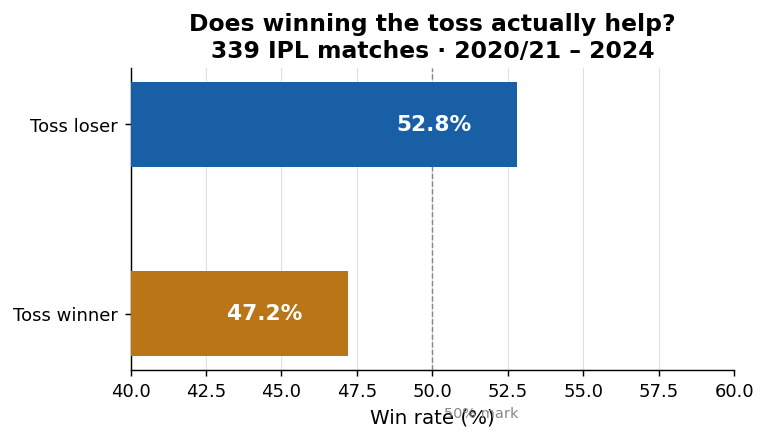


Key takeaway : Toss losers win more often (52.8%) than toss winners (47.2%).


In [14]:
labels   = ['Toss winner', 'Toss loser']
win_pcts = [toss_win_rate, toss_lose_rate]
colors   = ['#BA7517', '#185FA5']

fig, ax = plt.subplots(figsize=(6, 3.5))

bars = ax.barh(labels, win_pcts, color=colors, height=0.45, zorder=3)

# Add value label inside each bar
for bar, pct in zip(bars, win_pcts):
    ax.text(bar.get_width() - 1.5,
            bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', ha='right',
            color='white', fontsize=12, fontweight='bold')

# 50 % reference line
ax.axvline(50, color='#888888', linewidth=0.8, linestyle='--', zorder=2)
ax.text(50.4, -0.55, '50% mark', fontsize=8, color='#888888')

ax.set_xlim(40, 60)
ax.set_xlabel('Win rate (%)')
ax.set_title('Does winning the toss actually help?\n339 IPL matches · 2020/21 – 2024')
ax.grid(axis='x', color='#e0e0e0', linewidth=0.6, zorder=0)

plt.tight_layout()
plt.savefig('chart1_toss_effect.png', bbox_inches='tight')
plt.show()

print("\nKey takeaway : Toss losers win more often (52.8%) than toss winners (47.2%).")


## 3  Q2 — Which over phase is most linked to winning?

We split every innings into three phases:

| Phase | Overs |
|-------|-------|
| Powerplay | 1 – 6 |
| Middle overs | 7 – 15 |
| Death overs | 16 – 20 |

For each innings, we sum runs in each phase and flag whether that batting team won the match.  
We then compare the phase averages for winning and losing teams.


In [15]:
def label_phase(over):
    if over <= 5:
        return 'Powerplay'
    elif over <= 14:
        return 'Middle'
    else:
        return 'Death'

df['phase'] = df['over'].apply(label_phase)

# Map match winner back onto ball-by-ball rows
winner_map = matches.set_index('match_id')['winner'].to_dict()
df['match_winner'] = df['match_id'].map(winner_map)

# Flag: was the batting team the match winner?
df['batting_won'] = df['batting_team'] == df['match_winner']

# Sum runs per match × innings × phase × batting_won
phase_per_innings = (df.groupby(['match_id', 'innings', 'phase', 'batting_won'])
                       ['runs_total']
                       .sum()
                       .reset_index())

# Average those sums across all innings
phase_avg = (phase_per_innings
             .groupby(['phase', 'batting_won'])['runs_total']
             .mean()
             .round(1)
             .reset_index())

phase_avg.columns = ['Phase', 'batting_won', 'avg_runs']
phase_avg['Group'] = phase_avg['batting_won'].map({True: 'Winners', False: 'Losers'})
phase_avg['gap']   = None  # will fill below

print(phase_avg[['Phase','Group','avg_runs']].sort_values(['Phase','Group']))


       Phase    Group  avg_runs
0      Death   Losers      45.4
1      Death  Winners      49.3
2     Middle   Losers      68.8
3     Middle  Winners      76.9
4  Powerplay   Losers      46.8
5  Powerplay  Winners      53.2


### Chart 2 — Average runs per phase: winning innings vs losing innings

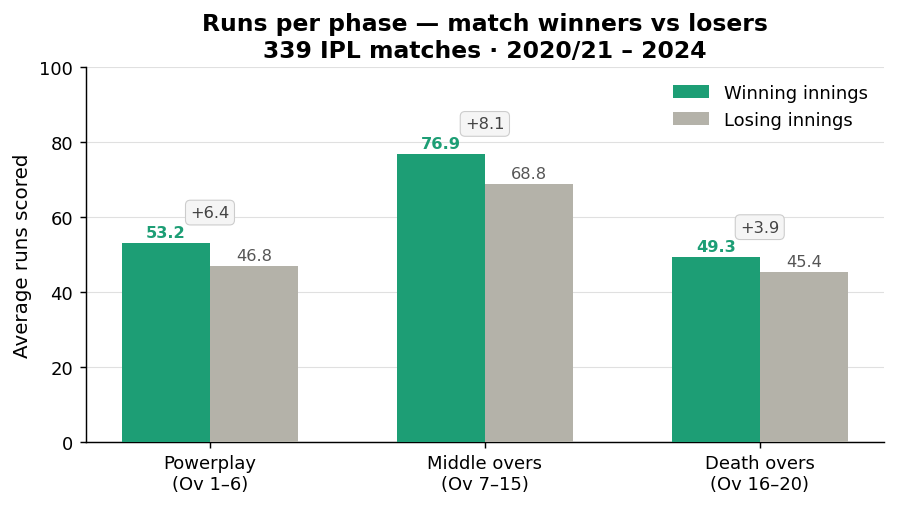

Key takeaway : Middle overs produce the largest gap (+8.1 runs).
Winning teams consistently outscore in all three phases, but
the middle-over margin is nearly double the death-over margin.


In [16]:
# Pivot for easier plotting
pivot = phase_avg.pivot(index='Phase', columns='Group', values='avg_runs')

# Fix display order
phase_order = ['Powerplay', 'Middle', 'Death']
pivot = pivot.loc[phase_order]

# Calculate gap for annotation
gaps = (pivot['Winners'] - pivot['Losers']).round(1)

x          = range(len(phase_order))
bar_w      = 0.32
win_color  = '#1D9E75'
lose_color = '#B4B2A9'

fig, ax = plt.subplots(figsize=(7, 4))

bar_w_pos = [i - bar_w / 2 for i in x]
bar_l_pos = [i + bar_w / 2 for i in x]

ax.bar(bar_w_pos, pivot['Winners'], width=bar_w, color=win_color,
       label='Winning innings', zorder=3)
ax.bar(bar_l_pos, pivot['Losers'],  width=bar_w, color=lose_color,
       label='Losing innings',  zorder=3)

# Annotate bar values
for pos, val in zip(bar_w_pos, pivot['Winners']):
    ax.text(pos, val + 0.8, str(val), ha='center', va='bottom',
            fontsize=9, color=win_color, fontweight='bold')

for pos, val in zip(bar_l_pos, pivot['Losers']):
    ax.text(pos, val + 0.8, str(val), ha='center', va='bottom',
            fontsize=9, color='#555555')

# Gap annotation above each group
for i, (gap, phase) in enumerate(zip(gaps, phase_order)):
    mid = i
    top = max(pivot.loc[phase]) + 6
    ax.text(mid, top, f'+{gap}', ha='center', va='bottom',
            fontsize=9, color='#444444',
            bbox=dict(boxstyle='round,pad=0.3', fc='#f5f5f5', ec='#cccccc', lw=0.6))

ax.set_xticks(list(x))
ax.set_xticklabels(['Powerplay\n(Ov 1–6)', 'Middle overs\n(Ov 7–15)', 'Death overs\n(Ov 16–20)'])
ax.set_ylabel('Average runs scored')
ax.set_title('Runs per phase — match winners vs losers\n339 IPL matches · 2020/21 – 2024')
ax.set_ylim(0, 100)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.6, zorder=0)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('chart2_phase_runs.png', bbox_inches='tight')
plt.show()

print("Key takeaway : Middle overs produce the largest gap (+8.1 runs).")
print("Winning teams consistently outscore in all three phases, but")
print("the middle-over margin is nearly double the death-over margin.")


## 4  Q3 — Top 5 batters and top 5 bowlers

**Batters :** summed `runs_batter` per player across all 5 seasons.  
**Bowlers :** counted dismissed deliveries, excluding run-outs (which are fielder dismissals, not bowler dismissals).


In [17]:
# ── Top batters ──────────────────────────────────────────────────────────────
top_batters = (df.groupby('batter')['runs_batter']
               .sum()
               .sort_values(ascending=False)
               .head(5)
               .reset_index())
top_batters.columns = ['Batter', 'Runs']
top_batters.index   = range(1, 6)

# ── Top bowlers (exclude run-outs) ───────────────────────────────────────────
wicket_balls = df[
    df['wicket_player_out'].notna() &
    (df['wicket_kind'].str.strip().str.lower() != 'run out')
].copy()

top_bowlers = (wicket_balls.groupby('bowler')
               .size()
               .sort_values(ascending=False)
               .head(5)
               .reset_index())
top_bowlers.columns = ['Bowler', 'Wickets']
top_bowlers.index   = range(1, 6)

print("=" * 35)
print("  TOP 5 BATTERS  (2020/21 – 2024)")
print("=" * 35)
print(top_batters.to_string())
print()
print("=" * 35)
print("  TOP 5 BOWLERS  (2020/21 – 2024)")
print("=" * 35)
print(top_bowlers.to_string())


  TOP 5 BATTERS  (2020/21 – 2024)
         Batter  Runs
1  F du Plessis  2718
2  Shubman Gill  2717
3      KL Rahul  2706
4       V Kohli  2592
5    RD Gaikwad  2380

  TOP 5 BOWLERS  (2020/21 – 2024)
           Bowler  Wickets
1       YS Chahal      105
2     Rashid Khan       94
3        HV Patel       92
4  Mohammed Shami       87
5        K Rabada       86


## 5  Surprising finding

In [18]:
# Quantify the toss-choice effect more precisely
bat_win_rate   = decision_rates.get('bat',   None)
field_win_rate = decision_rates.get('field', None)

print("Win rate when toss winner chose to BAT   :", bat_win_rate, "%")
print("Win rate when toss winner chose to FIELD :", field_win_rate, "%")
print()
print("Overall toss winner win rate             :", toss_win_rate, "%")
print()
# How many matches where toss winner chose bat?
bat_count   = (matches['toss_decision'] == 'bat').sum()
field_count = (matches['toss_decision'] == 'field').sum()
print(f"Matches where toss winner batted : {bat_count}")
print(f"Matches where toss winner fielded: {field_count}")
print()
print("SURPRISING FINDING:")
print("-" * 60)
print(
    f"Toss winners lost more matches than they won (47.2% win rate)."
    f"\nEven when they made the 'smart' choice to field first,"
    f"\nthey still only won {field_win_rate}% of the time — barely above chance."
    f"\nThis challenges the widespread belief that the toss is a"
    f"\nmeaningful advantage in T20 cricket."
)


Win rate when toss winner chose to BAT   : 42.9 %
Win rate when toss winner chose to FIELD : 49.0 %

Overall toss winner win rate             : 47.2 %

Matches where toss winner batted : 98
Matches where toss winner fielded: 241

SURPRISING FINDING:
------------------------------------------------------------
Toss winners lost more matches than they won (47.2% win rate).
Even when they made the 'smart' choice to field first,
they still only won 49.0% of the time — barely above chance.
This challenges the widespread belief that the toss is a
meaningful advantage in T20 cricket.


## 6  Summary of all three answers

In [19]:
summary = pd.DataFrame({
    'Question': [
        'Do toss winners win more?',
        'Best phase for winning?',
        'Top batter (runs)?',
        'Top bowler (wickets)?'
    ],
    'Answer': [
        f'No — toss winners win only {toss_win_rate}% of matches',
        'Middle overs (ov 7–15) — largest gap of +8.1 runs',
        f'{top_batters.iloc[0]["Batter"]} — {top_batters.iloc[0]["Runs"]:,} runs',
        f'{top_bowlers.iloc[0]["Bowler"]} — {top_bowlers.iloc[0]["Wickets"]} wickets'
    ],
    'Data source': [
        'match-level toss_winner vs winner',
        'phase-wise runs_total aggregation',
        'runs_batter sum per player',
        'wicket_player_out count (excl. run-outs)'
    ]
})

summary.index = range(1, len(summary) + 1)
print(summary.to_string(index=True))


                    Question                                             Answer                               Data source
1  Do toss winners win more?        No — toss winners win only 47.2% of matches         match-level toss_winner vs winner
2    Best phase for winning?  Middle overs (ov 7–15) — largest gap of +8.1 runs         phase-wise runs_total aggregation
3         Top batter (runs)?                          F du Plessis — 2,718 runs                runs_batter sum per player
4      Top bowler (wickets)?                            YS Chahal — 105 wickets  wicket_player_out count (excl. run-outs)
